<a href="https://colab.research.google.com/github/kushagragoyal300805/Applied-Machine-Learning-Lab_Experiments/blob/main/exp12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)
print("✓ Libraries loaded")

✓ Libraries loaded


In [11]:
X, y_true = make_blobs(n_samples=500,
                        centers=5,
                        cluster_std=0.9,
                        random_state=42)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('kmeans_clustering_2d_dataset.csv')
# X = df[['Feature_1','Feature_2']].values

print(df.head())
print(f"\nShape: {df.shape}")
print(df.describe().round(2))

   Feature_1  Feature_2
0   4.628857   1.165641
1   1.941538   5.457557
2   0.870026   4.946663
3   1.722738   1.051221
4  -8.563340  -7.196472

Shape: (500, 2)
       Feature_1  Feature_2
count     500.00     500.00
mean       -2.31       3.15
std         5.25       5.70
min       -11.27      -8.95
25%        -7.36       1.43
50%        -2.54       4.38
75%         2.62       7.78
max         6.72      11.46


In [5]:
# StandardScaler — mean=0, std=1 karta hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — mean:", X.mean(axis=0).round(2))
print("After  scaling — mean:", X_scaled.mean(axis=0).round(2))

Before scaling — mean: [-2.31  3.15]
After  scaling — mean: [-0.  0.]


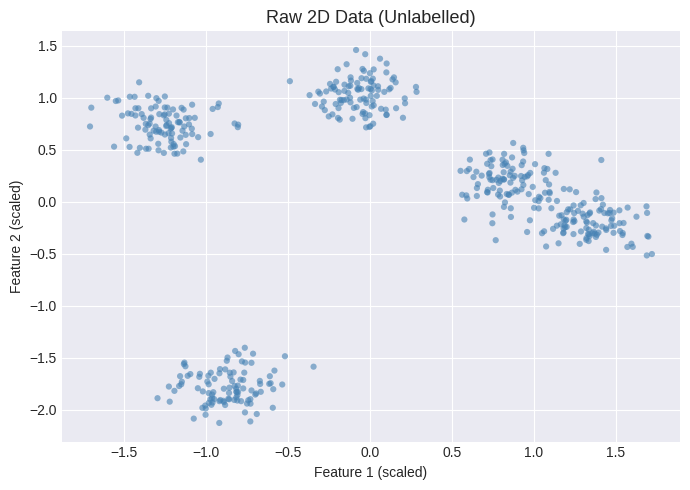

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_scaled[:,0], X_scaled[:,1],
           s=20, alpha=0.6, color='steelblue', edgecolors='none')
ax.set_title('Raw 2D Data (Unlabelled)', fontsize=13)
ax.set_xlabel('Feature 1 (scaled)')
ax.set_ylabel('Feature 2 (scaled)')
plt.tight_layout()
plt.show()

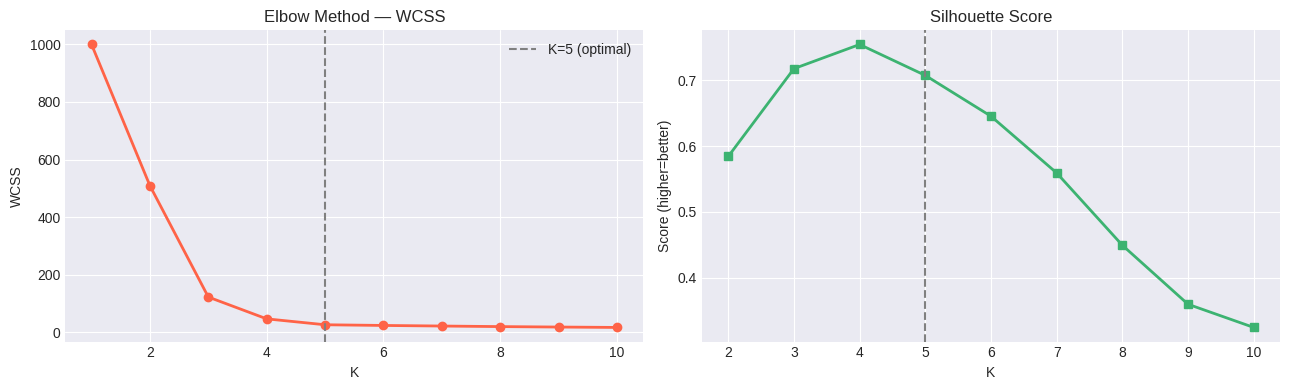

Best silhouette @ K=5: 0.7072


In [7]:
wcss = []
silhouette = []
K_range = range(2, 11)

for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    if k >= 2:
        score = silhouette_score(X_scaled, km.labels_)
        silhouette.append(score)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1,11), wcss, 'o-', color='tomato', linewidth=2)
axes[0].axvline(x=5, ls='--', color='gray', label='K=5 (optimal)')
axes[0].set_title('Elbow Method — WCSS')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')
axes[0].legend()

axes[1].plot(K_range, silhouette, 's-', color='mediumseagreen', linewidth=2)
axes[1].axvline(x=5, ls='--', color='gray')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score (higher=better)')

plt.tight_layout()
plt.show()
print(f"Best silhouette @ K=5: {silhouette[3]:.4f}")

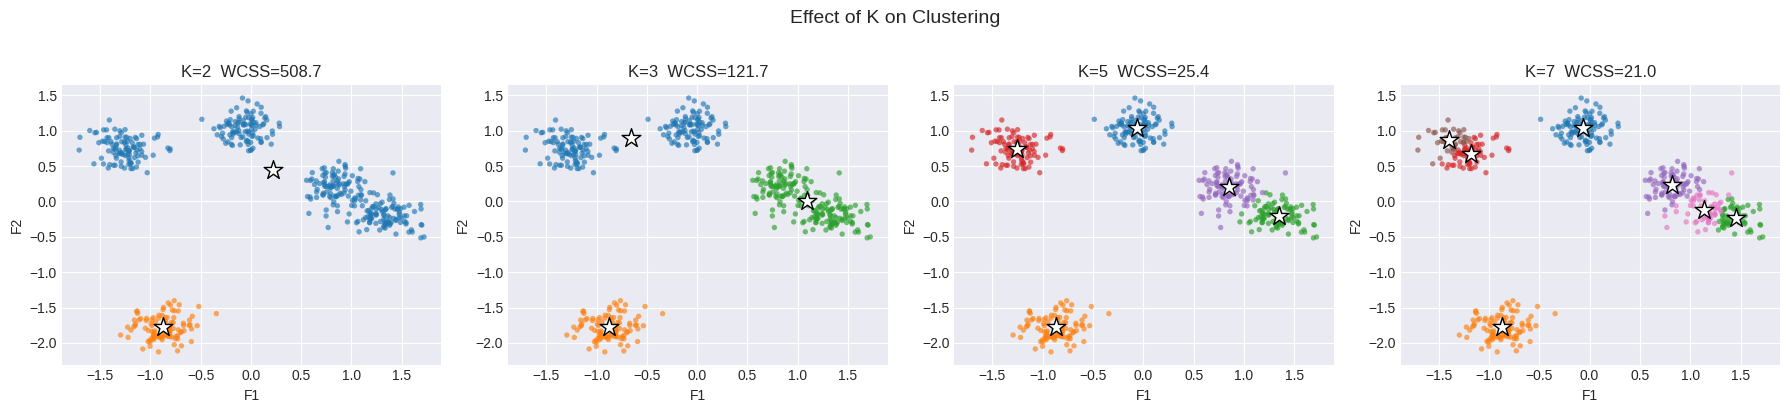

In [8]:
K_vals = [2, 3, 5, 7]
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, k in zip(axes, K_vals):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    for c in range(k):
        mask = labels == c
        ax.scatter(X_scaled[mask,0], X_scaled[mask,1],
                   s=15, alpha=0.65, color=colors[c], edgecolors='none')
    ax.scatter(*km.cluster_centers_.T, s=200, marker='*',
               c='white', edgecolors='black', zorder=5)
    ax.set_title(f'K={k}  WCSS={km.inertia_:.1f}')
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('Effect of K on Clustering', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

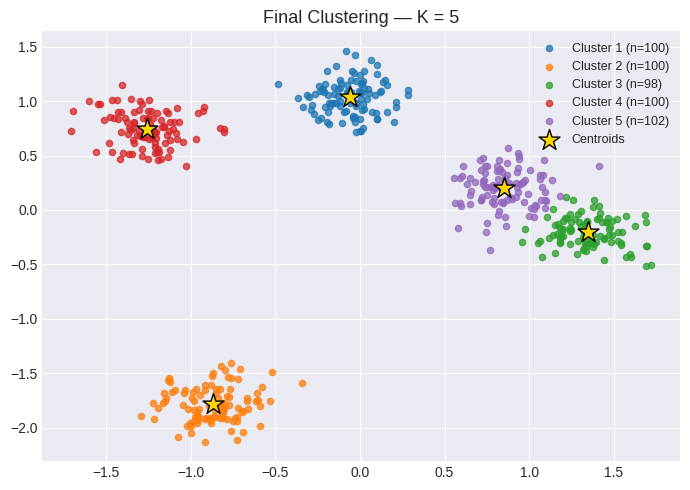

WCSS (Inertia)    : 25.3807
Iterations        : 3
Silhouette Score  : 0.7072

Centroid Coordinates:
  Cluster 1: (-0.061, 1.035)
  Cluster 2: (-0.871, -1.781)
  Cluster 3: (1.348, -0.206)
  Cluster 4: (-1.258, 0.744)
  Cluster 5: (0.853, 0.200)


In [9]:
km_final = KMeans(n_clusters=5, init='k-means++',
                  n_init=10, random_state=42)
labels_final = km_final.fit_predict(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
for c in range(5):
    mask = labels_final == c
    ax.scatter(X_scaled[mask,0], X_scaled[mask,1],
               s=20, alpha=0.75, label=f'Cluster {c+1} (n={mask.sum()})')
ax.scatter(*km_final.cluster_centers_.T, s=250, marker='*',
           c='gold', edgecolors='black', zorder=6, label='Centroids')
ax.set_title('Final Clustering — K = 5', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"WCSS (Inertia)    : {km_final.inertia_:.4f}")
print(f"Iterations        : {km_final.n_iter_}")
print(f"Silhouette Score  : {silhouette_score(X_scaled, labels_final):.4f}")
print("\nCentroid Coordinates:")
for i, c in enumerate(km_final.cluster_centers_):
    print(f"  Cluster {i+1}: ({c[0]:.3f}, {c[1]:.3f})")

In [10]:
df['Cluster'] = labels_final + 1
print("Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print("\nCluster-wise mean:")
print(df.groupby('Cluster').mean().round(3))
df.head(10)

Cluster distribution:
Cluster
1    100
2    100
3     98
4    100
5    102
Name: count, dtype: int64

Cluster-wise mean:
         Feature_1  Feature_2
Cluster                      
1           -2.630      9.038
2           -6.881     -6.984
3            4.765      1.976
4           -8.911      7.383
5            2.165      4.285


,Feature_1,Feature_2,Cluster
0,4.628857,1.165641,3
1,1.941538,5.457557,5
2,0.870026,4.946663,5
3,1.722738,1.051221,5
4,-8.563340,-7.196472,2
5,3.982549,2.167982,3
6,-5.828623,-6.651131,2
7,2.282552,6.371222,5
8,-2.242689,9.249236,1
9,-2.578589,9.321323,1
